In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.losses import Huber
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler

url = "http://127.0.0.1:5000"

# Data Loading

In [2]:
response = requests.get(f"{url}/stock/ml/BUMI")
json = response.json()
data = json.get('data')
df = pd.DataFrame(data)
df = df.drop(['attention_mask', 'content', 'content_abbreviation', 'content_clean', 'content_entity', 'content_stemmed', 'content_stopword_removed', 'emb_mean', 'embedding', 'sentiment_label', 'full_text', 'input_ids', 'negative_grouped_news_sentiment', 'positive_grouped_news_sentiment', 'title', 'title_abbreviation', 'title_clean', 'title_entity', 'title_stemmed', 'title_stopword_removed'], axis=1)
df["sentiment_score"] = df["sentiment_score"].apply(
    lambda x: [] if pd.isna(x) else ast.literal_eval(x)
)
df["foreign_net"] = df["foreign_buy"] - df["foreign_sell"]
df["Volume"] = np.log1p(df["Volume"])
df["value"] = np.log1p(df["value"])
df["foreign_buy"] = np.log1p(df["foreign_buy"])
df["foreign_sell"] = np.log1p(df["foreign_sell"])
df["bid_volume"] = np.log1p(df["bid_volume"])
df["offer_volume"] = np.log1p(df["offer_volume"])
df

,Close,Close_ihsg,High,Low,Open,Volume,bid_value,bid_volume,date,ema100,...,sma50,stoch_rsi_d%,stoch_rsi_k%,ub_bolinger,value,wma100,wma20,wma5,wma50,foreign_net
0,66.0,6283.581055,67.0,66.0,66.0,17.657965,66.0,16.559578,2020-01-02,66.000000,...,0.00,0.000000,0.000000,0.000000,21.855228,0.000000,0.000000,0.000000,0.000000,-7720600.0
1,73.0,6323.465820,74.0,66.0,66.0,20.185856,72.0,16.889777,2020-01-03,66.138614,...,0.00,0.000000,0.000000,0.000000,24.443373,0.000000,0.000000,0.000000,0.000000,11078200.0
2,69.0,6257.402832,73.0,68.0,73.0,19.777121,68.0,16.985091,2020-01-06,66.195275,...,0.00,0.000000,0.000000,0.000000,24.033697,0.000000,0.000000,0.000000,0.000000,-126054900.0
3,69.0,6279.346191,70.0,68.0,69.0,18.484374,68.0,17.254636,2020-01-07,66.250814,...,0.00,0.000000,0.000000,0.000000,22.716842,0.000000,0.000000,0.000000,0.000000,-15032900.0
4,68.0,6225.686035,69.0,66.0,69.0,18.974357,67.0,16.705588,2020-01-08,66.285451,...,0.00,0.000000,0.000000,0.000000,23.182099,0.000000,0.000000,46.000000,0.000000,-4583400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1571,147.0,6037.841797,148.0,139.0,142.0,21.386982,147.0,18.090258,2026-07-13,194.060024,...,169.62,80.338110,77.213786,170.558606,26.351984,226.338416,140.252381,92.800000,178.606275,266024800.0
1572,149.0,6039.520996,155.0,146.0,148.0,21.963438,148.0,18.205629,2026-07-14,193.167746,...,167.80,54.644945,9.507265,168.805257,26.977335,225.675644,137.933333,93.200000,175.846275,-144472200.0
1573,148.0,6041.972168,152.0,147.0,150.0,20.994785,147.0,17.889761,2026-07-15,192.273335,...,166.16,37.309350,25.207001,167.518626,26.002531,224.836436,135.976190,95.533333,173.407059,-287818500.0
1574,149.0,6108.208984,152.0,147.0,148.0,21.166431,149.0,16.941977,2026-07-16,191.416437,...,164.54,11.571422,0.000000,165.823727,26.173223,223.502178,133.638095,97.000000,170.903529,-335497100.0


In [3]:
df = df.dropna()

In [4]:
df.columns

Index(['Close', 'Close_ihsg', 'High', 'Low', 'Open', 'Volume', 'bid_value',
       'bid_volume', 'date', 'ema100', 'ema20', 'ema5', 'ema50', 'foreign_buy',
       'foreign_sell', 'lb_bolinger', 'macd_hist', 'macd_line', 'macd_signal',
       'mb_bolinger', 'mean_sentiment_score_negative',
       'mean_sentiment_score_positive', 'offer_value', 'offer_volume',
       'percent_bolinger', 'psar', 'return', 'return_num', 'rsi',
       'sentiment_pca_0', 'sentiment_pca_1', 'sentiment_pca_10',
       'sentiment_pca_11', 'sentiment_pca_12', 'sentiment_pca_13',
       'sentiment_pca_14', 'sentiment_pca_15', 'sentiment_pca_16',
       'sentiment_pca_17', 'sentiment_pca_18', 'sentiment_pca_19',
       'sentiment_pca_2', 'sentiment_pca_20', 'sentiment_pca_21',
       'sentiment_pca_22', 'sentiment_pca_23', 'sentiment_pca_24',
       'sentiment_pca_25', 'sentiment_pca_26', 'sentiment_pca_27',
       'sentiment_pca_28', 'sentiment_pca_29', 'sentiment_pca_3',
       'sentiment_pca_30', 'sentiment_pca

In [5]:
df.describe()

,Close,Close_ihsg,High,Low,Open,Volume,bid_value,bid_volume,ema100,ema20,...,sma50,stoch_rsi_d%,stoch_rsi_k%,ub_bolinger,value,wma100,wma20,wma5,wma50,foreign_net
count,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,...,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1.576000e+03
mean,110.270305,6698.155363,113.933376,107.547589,110.696066,19.847022,101.276015,14.728050,106.356905,109.779043,...,106.982487,49.342611,49.600333,130.660478,24.380851,99.314341,98.464431,73.295389,102.261940,-5.072121e+07
std,63.542506,943.859524,66.532341,61.095254,63.989847,2.329940,71.686703,6.132760,52.230905,61.370935,...,62.207030,36.462863,39.172492,89.990666,2.888255,59.418264,57.456183,42.380200,60.547052,3.662403e+08
min,50.000000,0.000000,50.000000,50.000000,50.000000,0.000000,0.000000,0.000000,50.377633,50.000012,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.587476e+09
25%,62.000000,6158.311401,64.000000,60.000000,62.000000,19.174770,60.000000,15.179781,64.229015,62.504253,...,61.895000,12.242466,0.000000,70.144686,23.491520,60.294406,55.722619,41.133333,59.096667,-6.449900e+07
50%,96.000000,6856.133545,100.000000,93.500000,96.000000,20.106730,93.000000,17.047747,98.964263,94.067463,...,92.040000,51.838912,54.374232,114.952922,24.736585,88.118614,84.650000,63.333333,87.819608,-1.912250e+06
75%,136.250000,7187.029175,141.000000,133.000000,137.000000,21.182397,135.000000,17.986823,127.334188,135.604665,...,132.725000,85.438871,89.275813,153.934904,25.903124,124.695446,122.857143,90.750000,127.061569,2.192355e+07
max,464.000000,9134.700195,484.000000,456.000000,470.000000,24.076693,464.000000,21.654616,266.331516,398.143060,...,338.960000,100.000000,100.000000,560.491098,29.681847,312.672871,385.285714,307.466667,351.366275,2.762691e+09


# Data Preprocessing

# Addons Data

## RSI

Indikator ini merupakan indikator momentum yang dapat menjadi tolak ukur investor menentukan titik beli dan titik jual suatu saham [5]. Indikator ini di normalisasi dari skala 1 – 100 dengan area dibawah 30 merupakan area jenuh jual (oversold) dan area diatas 70 adalah area jenuh beli (overbought) [6]. Persamaan yang digunakan dalam menghitung RSI suatu periode saham adalah 

$$ RSI = 100 - \frac{100}{1 + RS} $$
$$ RS = \frac{SMA(U)}{SMA(D)}$$

RSI: Relative Strength Index

RS: Relative Strength

SMA(U): Simple Moving Average Up (Jika harga naik, U = Change, D = 0)

SMA(D): Simple Moving Average Down (Jika harga turun, U = 0, D = Change). Jika harga tetap, U = 0, D = 0.

Indikator ini kemudian dikembangkan dengan membandingkan harga saat ini dengan rata-rata nya yang disebut dengan Stochastik RSI (Stoch). 

$$Stoch(K\%) = \frac{(RSI - min(RSI))}{(max(RSI) - min(RSI))} \times 100 $$
$$D\% = SMA(K\%)$$

Dengan:

$K\%$ = Normalisasi RSI ke skala 0-1 dikali 100

$D\%$ = Rata - rata K% selama 3 hari

## MACD (Moving Average Convergence/Divergence)

merupakan indikator trend (Trend Indicator) yang menampilkan perbedaan antara pergerakan harga exponential rata-rata (Exponential  Moving Average (EMA)) yang lebih cepat atau lebih lambat dari harga penutupan (Close Price) [5]. Indikator ini dirancang untuk mengidentifikasi perubahan yang terjadi pada trend, namun tidak direkomendasikan untuk digunakan untuk pasar dengan kondisi yang volatile. Terdapat 3 signal yang diberikan dari indikator MACD ini, yaitu [5]:

1.	MACD menyilang dengan garis sinyal (Signal Line)
2.	MACD menyilang dengan garis 0
3.	Perbedaan antara harga dan level MACD. 

3 signal dari indikator MACD diatas merupakan sinyal beli jika MACD menyilang ke atas terhadap signal line dan akan menjadi sinyal jual jika MACD menyilang ke bawah terhadap signal line [5]. Histogram pada MACD juga dapat menjadi petunjuk jika persilangan akan segera terjadi [5] dan menjadi tanda kekuatan sinyal yang diberikan, yaitu jika menyilang ke atas dibawah histogram menandakan sinyal beli lemah, jika menyilang ke atas diatas histogram menandakan sinyal beli kuat, jika menyilang kebawah diatas histogram menandakan sinyal jual lemah, jika menyilang kebawah dibawah histogram menandakan sinyal jual kuat [6]. 

$$MACD_{line} = EMA(12)_{t} - EMA(26)_{t}$$
$$Signal_{line} = EMA(9)_{MACD_{line}}$$
$$Histogram = MACD_{line} - Signal_{line}$$


## Moving Average

Moving Averages (MA) merupakan indikator teknikal yang mencerminkan harga rata-rata dari nilai pergerakan suatu saham di dalam waktu tertentu dengan rentang waktu sesuai dengan yang diatur oleh investor [4]. Terdapat 3 jenis MA, yaitu Simple Moving Averages (SMA), Weighted Moving Average (WMA), dan Exponential Moving Average (EMA) [6].

Perbedaan dari ketiga jenis MA tersebut [6], SMA merupakan rata-rata dari nilai pergerakan suatu saham di waktu tertentu dan rentang waktu tertentu secara sederhana dengan kekurangannya yang menganggap semua periode sebelumnya sama pentingnya dalam pembentukan trend, walaupun angka penutupan lebih efektif dalam membentuk pergerakan harga. WMA merupakan MA yang dirancang untuk menutupi kekurangan dari SMA dengan harga pada suatu periode diberi bobot sesuai dengan urutan seri yang membuatnya memiliki bobot yang lebih besar diberikan pada pergerakan harga terbaru, namun hal ini masih menimbulkan kekurangan berupa noise karena bobot yang diterapkan pada keseluruhan data. EMA dirancang untuk mengurangi noise dari WMA dan mengekspresikan pergerakan harga terbaru dengan lebih kuat. Hal ini dikarenakan EMA dihitung secara rekursif berdasarkan periode sebelumnya yang memberikan penghalusan yang baik dan mengurangi banyak noise.

$$SMA(n)_{t} = \frac{\sum_{i=1}^{n} A_{i}}{n} = \overline{x}n_{t} = EMA(n)_{1}$$
$$WMA(n)_{t} = \frac{\sum_{i=1}^{n} A_{i}(n - i)}{\frac{n(n+1)}{2}}$$
$$EMA(n)_{t} = A_{t}(\frac{2}{n+1}) + EMA(n)_{t-1}(1 - \frac{2}{n+1})$$

dengan

$SMA(n)_{t}$ = Simple moving average

$WMA(n)_{t}$ = Weighted Moving Average

$EMA(n)_{t}$ = Exponential Moving Average

$\overline{x}n_{t}$ = rata rata harga saham pada waktu ke t

$A_{i}$, $A_{t}$ = harga saham pada periode ke-i atau periode ke-t

## Boolinger Bands

Indikator ini merupakan salah satu indikator teknikal berguna dalam mendapatkan informasi apakah pasar memiliki volatilitas yang tinggi atau rendah (Volatility Indicator) [5]. Indikator ini melibatkan perhitungan volatilitas harga dan bekerja dengan dua garis batas, yaitu batas atas dan batas bawah serta garis batas tengah mengikuti rata-rata pergerakan harga sepanjang periode tertentu. Batas atas disebut dengan upperband, batas bawah disebut dengan lowerband, dan garis tengah disebut dengan middle band [4]. Perlu diketahui, nilai volatilitas yang berada dalam interval positif, yaitu dari 0 hingga $\infty (0\ \le\ \sigma\le\ \infty)$ menunjukkan harga saham berubah, bila rendah, dapat dikatakan konstan. Bila \sigma^2 tidak diketahui, grafik batas BB dari SMA periode ke-n pada waktu ke-t adalah:

$$\sigma_{B(n)_{t}} = \sqrt{\frac{\sum_{i=1}^{n}(X_{i} - \overline{X}(n)_{t})^{2}}{n}}$$
$$LB(n)_{t} = \overline{X}(n)_{t} - k\sigma_{B(n)_{t}}$$
$$MB(n)_{t} = \overline{X}(n)_{t}$$
$$UB(n)_{t} = \overline{X}(n)_{t} + k\sigma_{B(n)_{t}}$$

dengan

$\sigma_{B(n)_{t}}$ = Volatilitas Harga

$LB(n)_{t}$ = Lowerband

$MB(n)_{t}$ = Middleband

$UB(n)_{t}$ = Upperband

$n$ = banyak data harga saham (standar yang disarankan bernilai 20)

$X$ = Harga saham

$k$ = ketentuan nilai koefisien (standar yang disarankan 2)

$\overline{X}(n)_{t}$ = SMA periode ke t

Percent Bollinger Band (PBB) adalah indikator yang didapatkan dari pergerakan garis elastis upperband dan lowerband. Apabila PBB lebih dari 1, pergerakan harga berada di atas garis elastis upperband. Sebaliknya, jika PBB kurang dari 0, pergerakan harga berada dibawah garis lower band. Disaat nilai PBB adalah 0.5, pergerakan harga tepat berada dalam middle band [4]. Persamaan yang digunakan adalah: 

$$PBB(n)_{t} = \frac{X_{t} - LB(n)_{t}}{UB(n)_{t} - LB(n)_{t}}$$

dengan: 
$PBB(n)_{t}$ = Percent Bolinger Bands pada harga saham ke n

## Return

Indikator teknikal berikut digunakan untuk mengetahui berapakah hasil yang didapatkan ketika berinvestasi berdasarkan capital gain atau capital loss dari suatu index saham [4]. Persamaan yang digunakan adalah

$$R(n)_{t} = ln(\frac{X(n)}{X(n-t)})$$

dengan $X(n)$ adalah data saham pada periode ke-n

## Parabolic Stop and Reversal (PSAR)

Indikator yang digunakan untuk menangkap harga saat ini dan perubahan trend [6]. Jika harga < PSAR berarti sinyal beli. Jika harga > PSAR berarti sinyal jual.

$$PSAR = C + AF(EPT - C)$$

dengan
$PSAR$ = Parabolic stop and reversal

$C$ = Nilai $PSAR$ periode sebelumnya

$AF$ = Acceleration Factor (percepatan agar $SAR$ mendekati harga saat trend semakin kuat (awal: 0.02, $EP$ Baru -> +0.02, Max: 0.2, Reset ketika harga < $PSAR$))

$EPT$ = Extreme Point (titik harga paling ekstrem (highest high: uptrend, lowest low: downtrend))

## Data Correlation

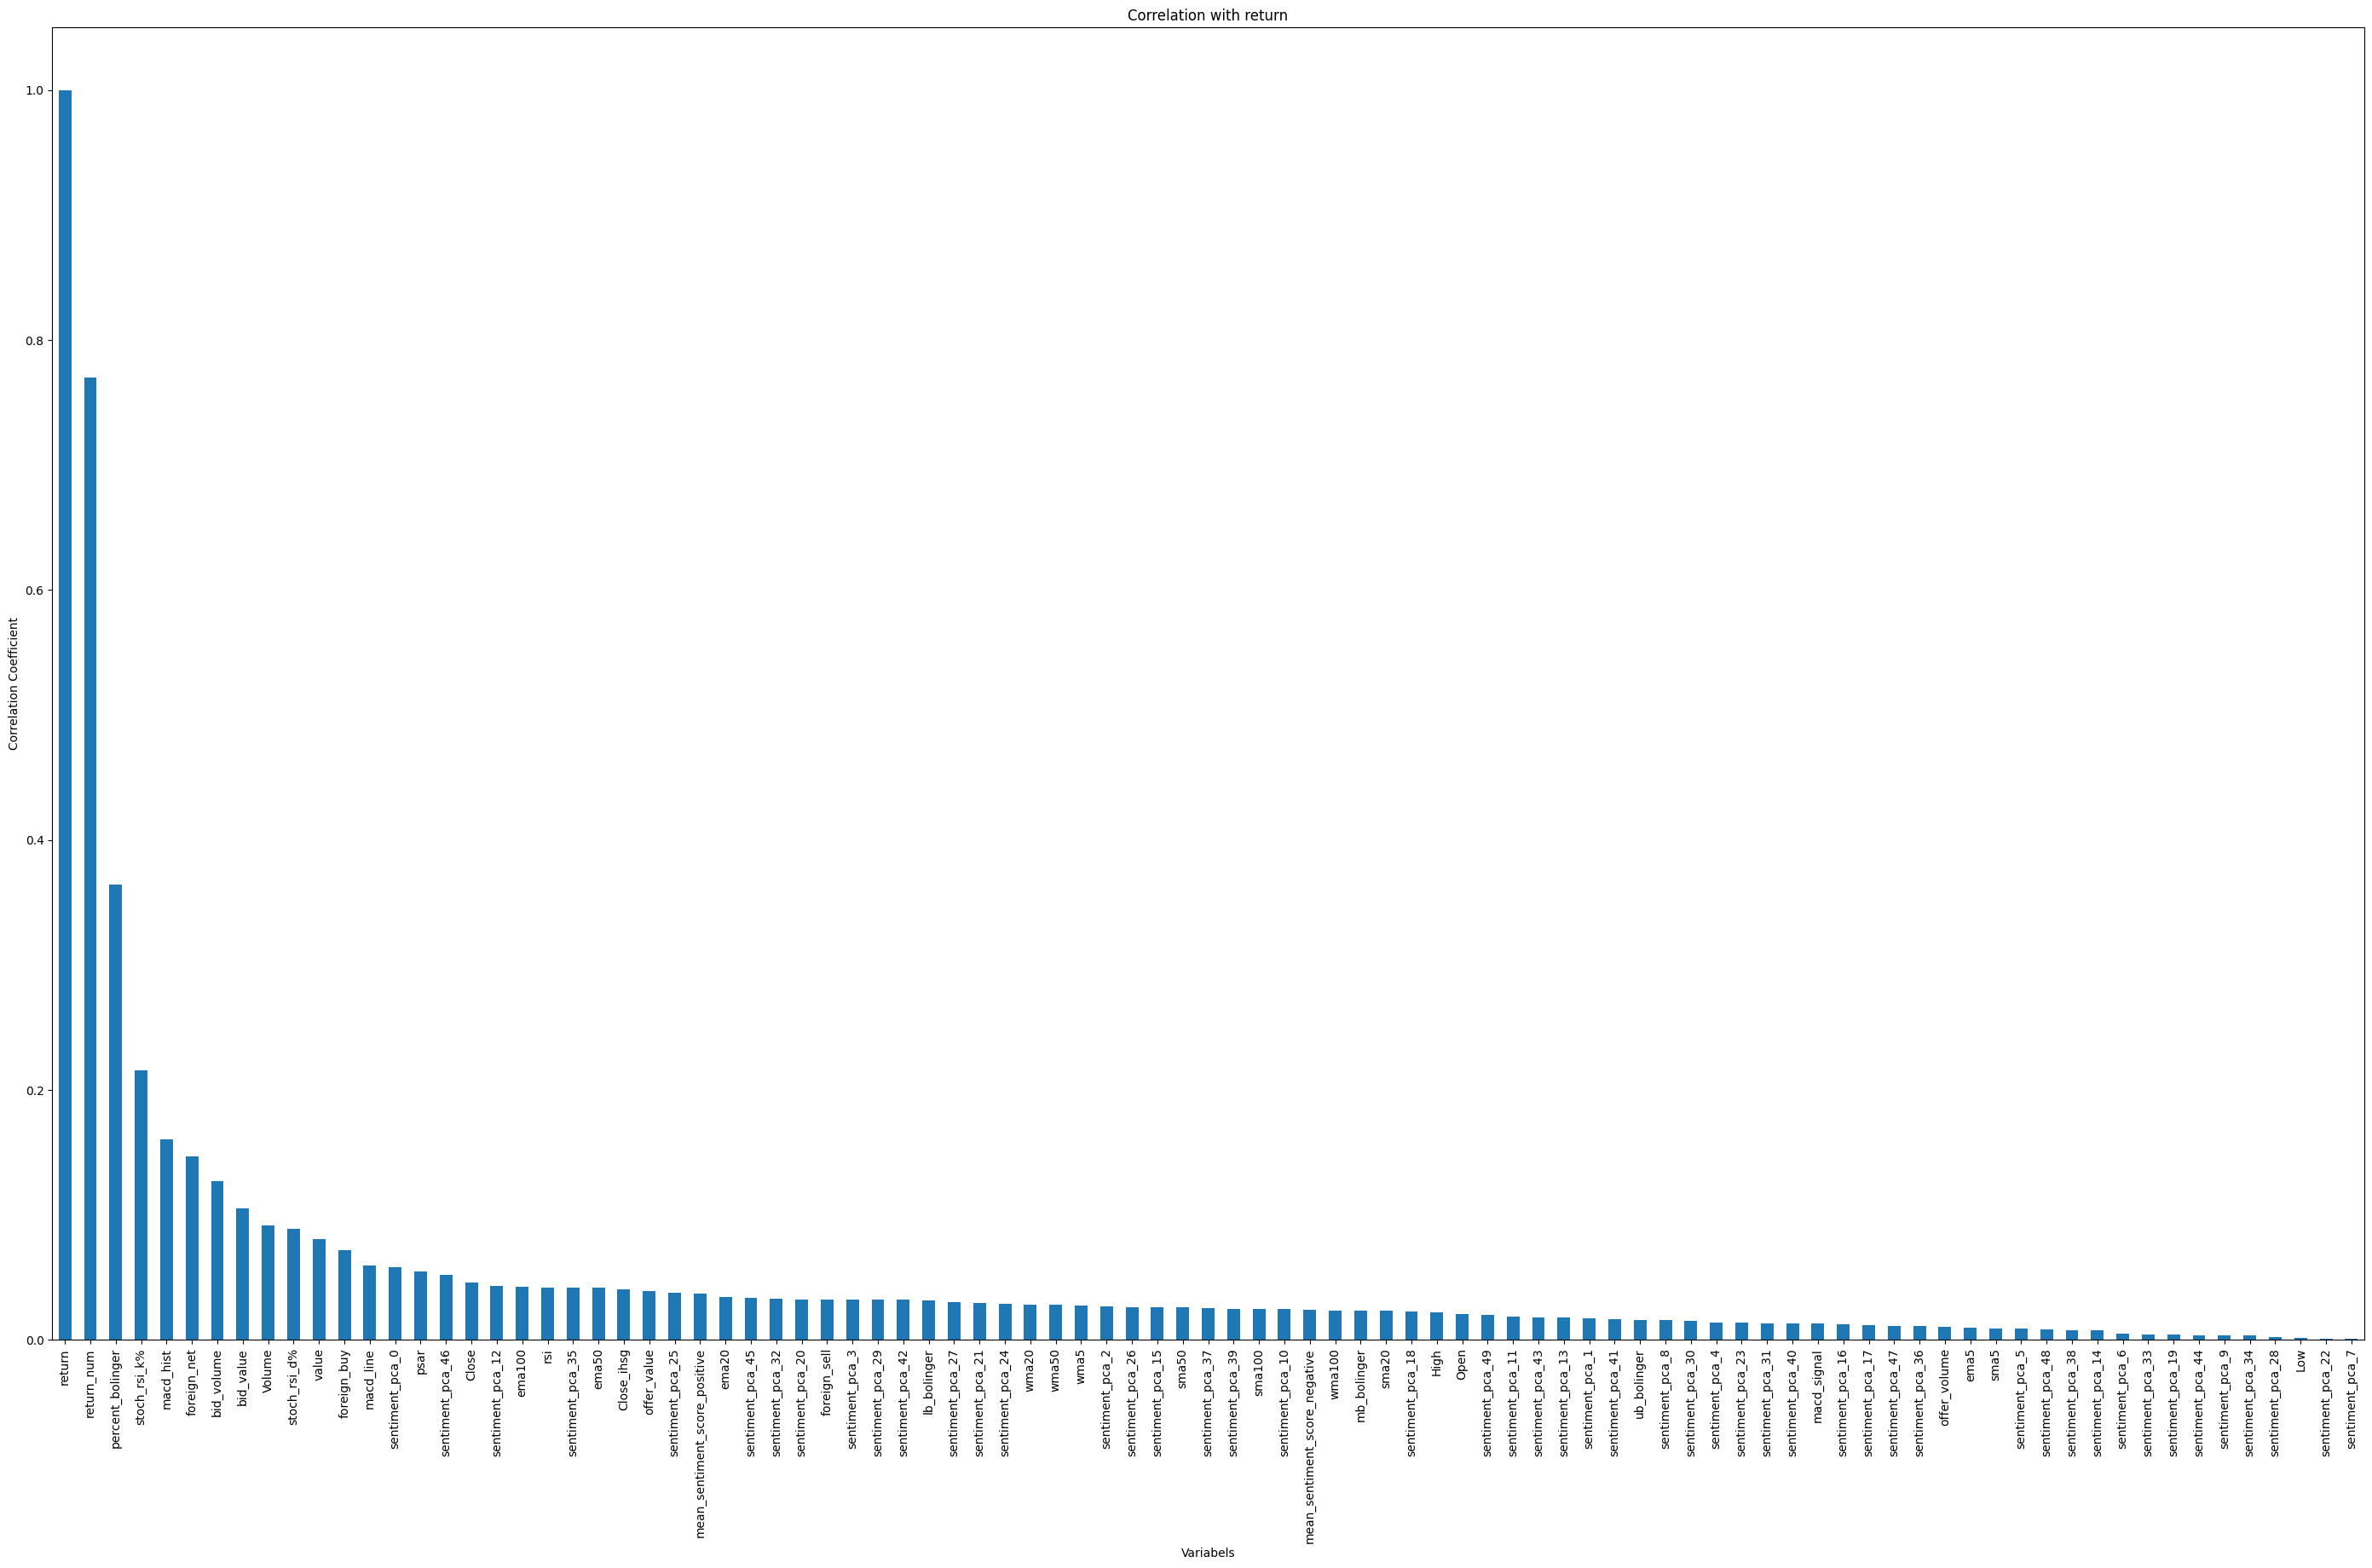

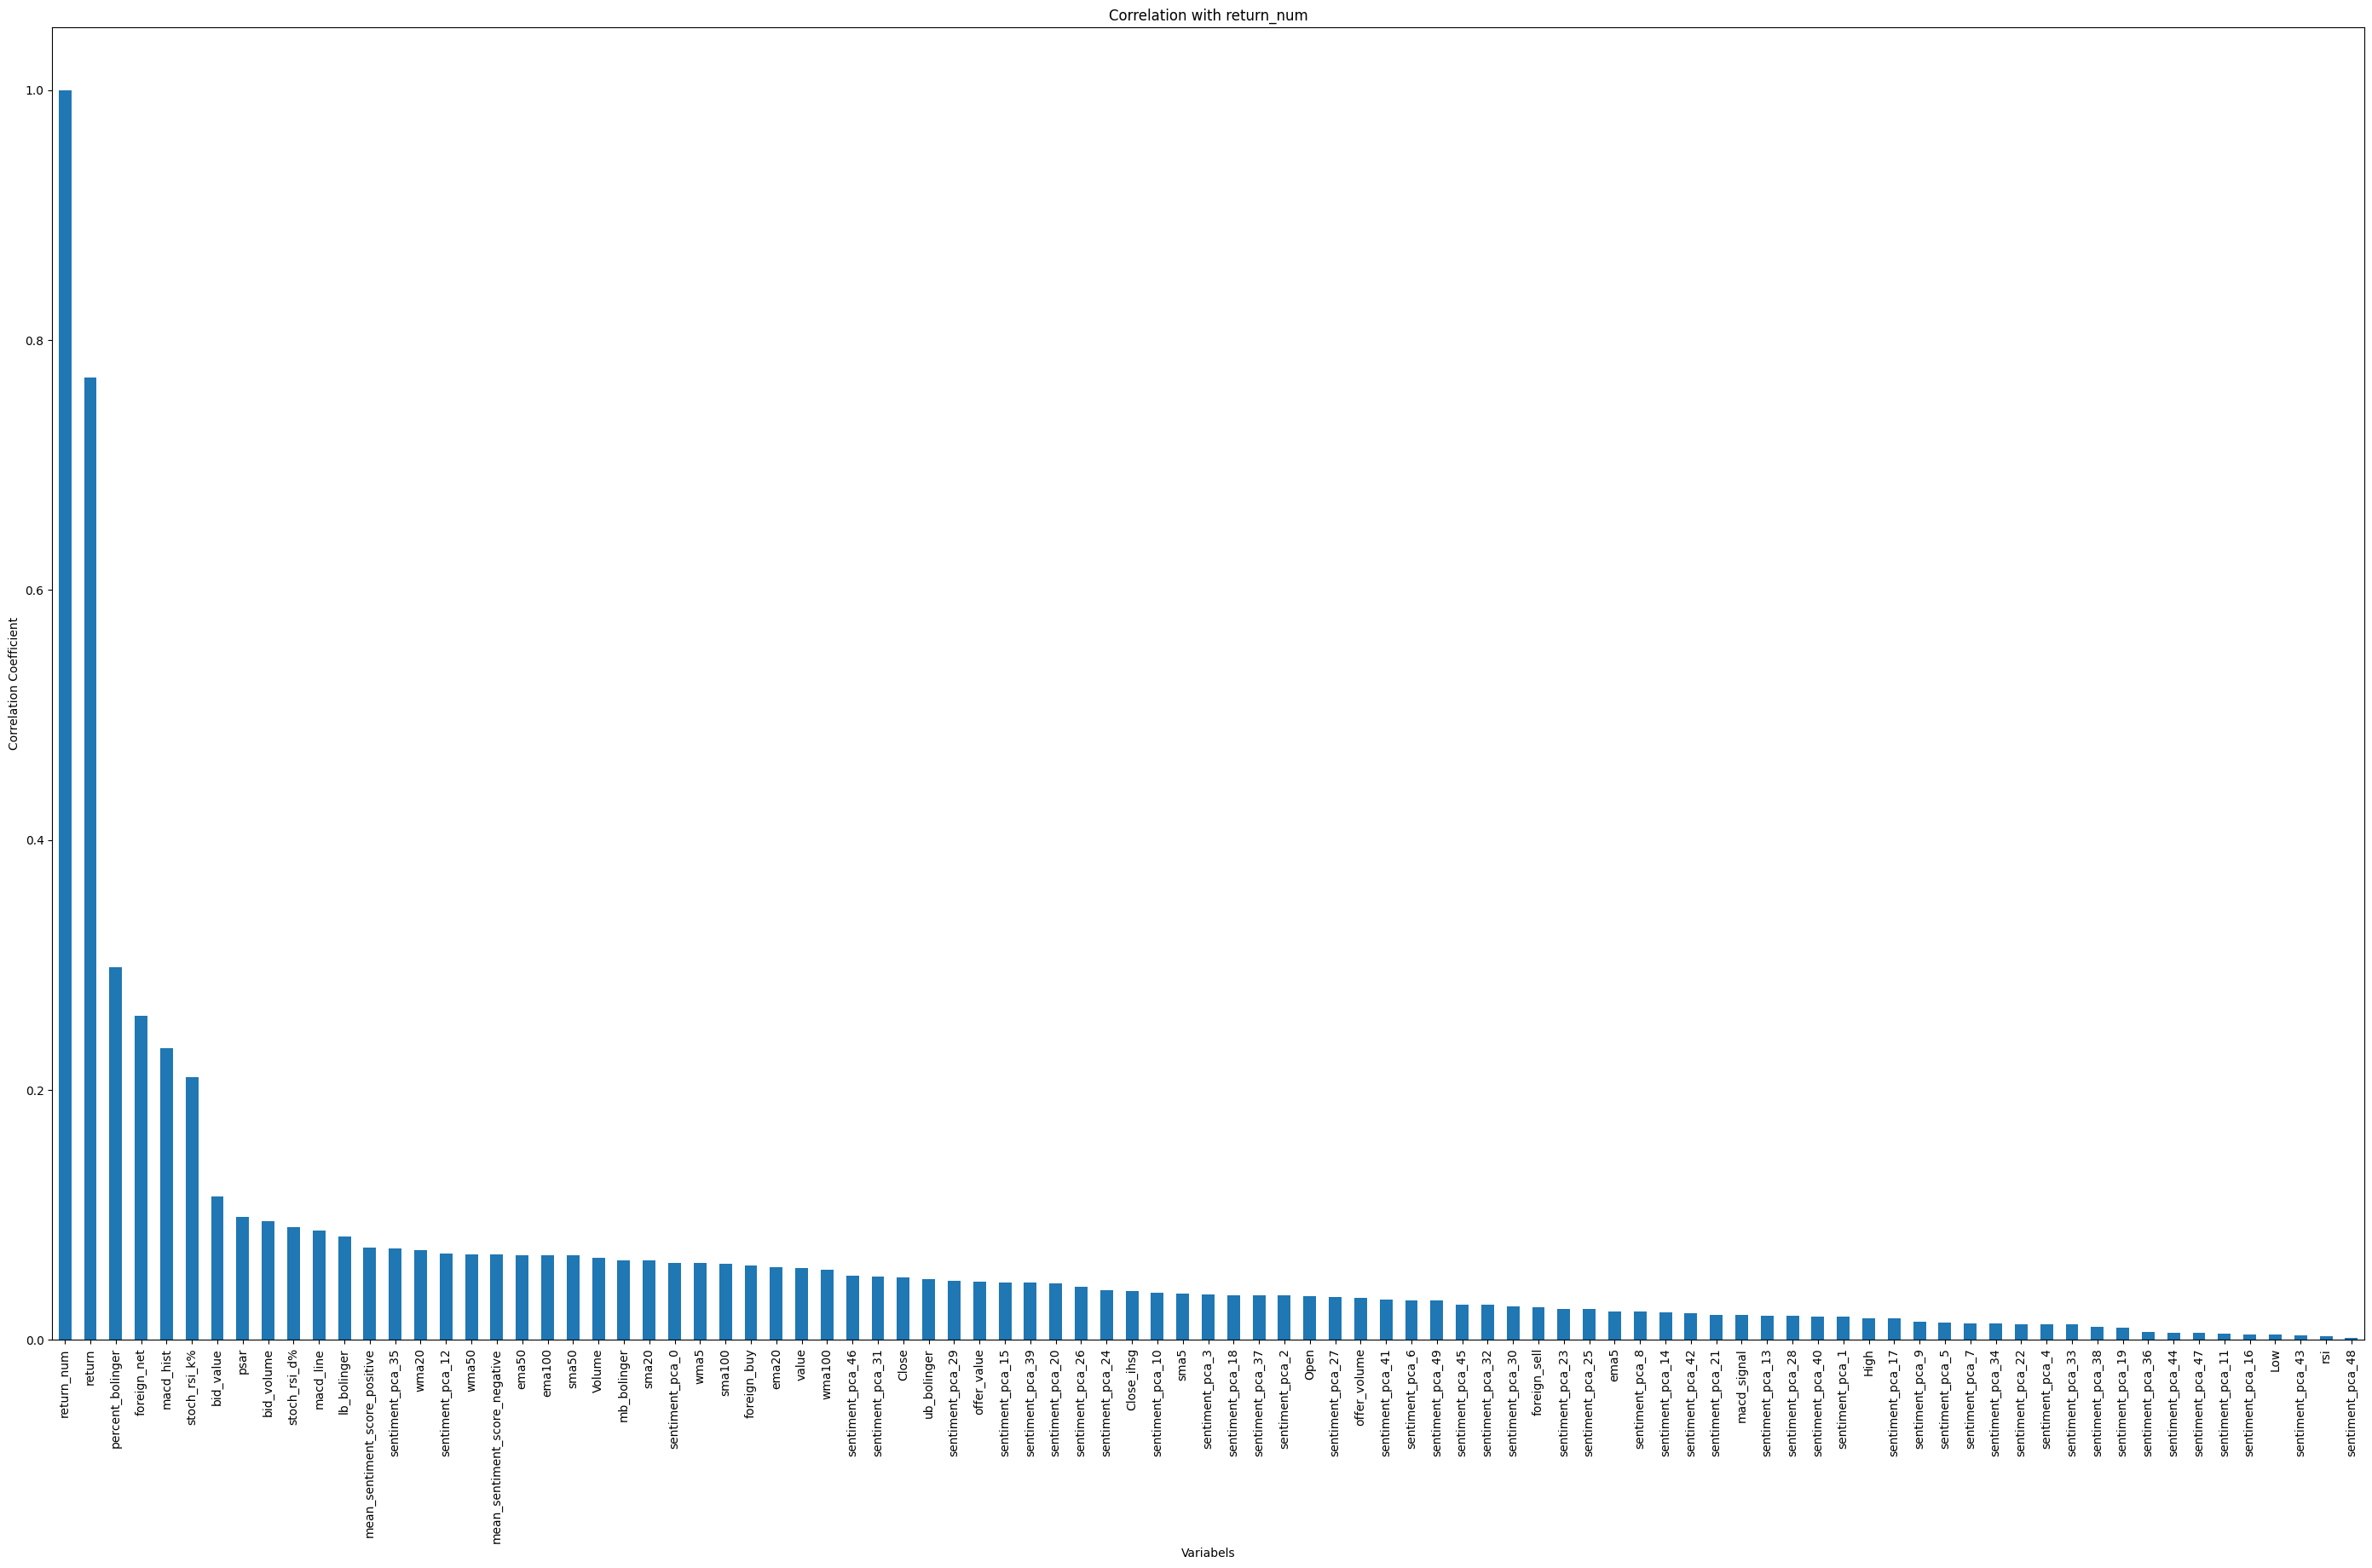

In [6]:
for i in ['return', 'return_num']:
    target_corr = df.select_dtypes(include=['number']).corr()[i]
    target_corr_sorted = target_corr.abs().sort_values(ascending=False)

    plt.figure(figsize=(35, 20))
    target_corr_sorted.plot(kind='bar')
    plt.title(f'Correlation with {i}')
    plt.xlabel('Variabels')
    plt.ylabel('Correlation Coefficient')
plt.show()

## Feature Engineering

### Non Linear Auto Regression feature

In [7]:
features = df.columns.drop(['date', 'return', 'return_num', 'sentiment_score'])
df["return"]
X = df[features]

y = df['return_num']

In [8]:
X

,Close,Close_ihsg,High,Low,Open,Volume,bid_value,bid_volume,ema100,ema20,...,sma50,stoch_rsi_d%,stoch_rsi_k%,ub_bolinger,value,wma100,wma20,wma5,wma50,foreign_net
0,66.0,6283.581055,67.0,66.0,66.0,17.657965,66.0,16.559578,66.000000,66.000000,...,0.00,0.000000,0.000000,0.000000,21.855228,0.000000,0.000000,0.000000,0.000000,-7720600.0
1,73.0,6323.465820,74.0,66.0,66.0,20.185856,72.0,16.889777,66.138614,66.666667,...,0.00,0.000000,0.000000,0.000000,24.443373,0.000000,0.000000,0.000000,0.000000,11078200.0
2,69.0,6257.402832,73.0,68.0,73.0,19.777121,68.0,16.985091,66.195275,66.888889,...,0.00,0.000000,0.000000,0.000000,24.033697,0.000000,0.000000,0.000000,0.000000,-126054900.0
3,69.0,6279.346191,70.0,68.0,69.0,18.484374,68.0,17.254636,66.250814,67.089947,...,0.00,0.000000,0.000000,0.000000,22.716842,0.000000,0.000000,0.000000,0.000000,-15032900.0
4,68.0,6225.686035,69.0,66.0,69.0,18.974357,67.0,16.705588,66.285451,67.176619,...,0.00,0.000000,0.000000,0.000000,23.182099,0.000000,0.000000,46.000000,0.000000,-4583400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1571,147.0,6037.841797,148.0,139.0,142.0,21.386982,147.0,18.090258,194.060024,146.732431,...,169.62,80.338110,77.213786,170.558606,26.351984,226.338416,140.252381,92.800000,178.606275,266024800.0
1572,149.0,6039.520996,155.0,146.0,148.0,21.963438,148.0,18.205629,193.167746,146.948390,...,167.80,54.644945,9.507265,168.805257,26.977335,225.675644,137.933333,93.200000,175.846275,-144472200.0
1573,148.0,6041.972168,152.0,147.0,150.0,20.994785,147.0,17.889761,192.273335,147.048543,...,166.16,37.309350,25.207001,167.518626,26.002531,224.836436,135.976190,95.533333,173.407059,-287818500.0
1574,149.0,6108.208984,152.0,147.0,148.0,21.166431,149.0,16.941977,191.416437,147.234396,...,164.54,11.571422,0.000000,165.823727,26.173223,223.502178,133.638095,97.000000,170.903529,-335497100.0


In [9]:
y

0       0.0
1       7.0
2      -4.0
3       0.0
4      -1.0
       ... 
1571    5.0
1572    2.0
1573   -1.0
1574    1.0
1575    1.0
Name: return_num, Length: 1576, dtype: float64

Hitung korelasi Pearson antara setiap fitur dan target. Pilih fitur yang nilai absolut korelasinya > 0.1.

- Mengapa threshold 0.3? Karena di bawah itu, hubungan linear sangat lemah fitur seperti Volume_Change biasanya di bawah 0.1 dan cenderung hanya menambah noise.

- Catatan: Korelasi linear tidak menangkap hubungan non-linear, tetapi untuk langkah awal penyaringan cukup baik. Model CNN-LSTM nanti bisa menangkap pola non-linear dari fitur yang tersisa.

# Data Splitting

In [10]:
split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

## Data Normalization

In [11]:
scale_columns = [
    "Volume",
    "value",
    "bid_volume",
    "offer_volume",
    "bid_value",
    "offer_value",
    "foreign_sell",
    "foreign_buy",
    "foreign_net",
    "Open",
    "High",
    "Low",
    "Close",
    'Close_ihsg',
    'ema100', 'ema20', 'ema5', 'ema50',
    'sma100', 'sma20', 'sma5', 'sma50',
    'wma100', 'wma20', 'wma5', 'wma50',
    'lb_bolinger', 'mb_bolinger', 'ub_bolinger',
    'macd_hist', 'macd_line', 'macd_signal',
    'psar'
]

standard_scaler = StandardScaler()
y_standard_scaler = StandardScaler()

X_train[scale_columns] = standard_scaler.fit_transform(X_train[scale_columns])
X_test[scale_columns] = standard_scaler.transform(X_test[scale_columns])
y_train = pd.Series(y_standard_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten())
y_test = pd.Series(y_standard_scaler.transform(y_test.values.reshape(-1, 1)).flatten())

In [12]:
X_train

,Close,Close_ihsg,High,Low,Open,Volume,bid_value,bid_volume,ema100,ema20,...,sma50,stoch_rsi_d%,stoch_rsi_k%,ub_bolinger,value,wma100,wma20,wma5,wma50,foreign_net
0,-0.671768,-0.318070,-0.688944,-0.640270,-0.672768,-0.867659,-0.318024,0.363133,-0.720100,-0.683186,...,-2.178476,0.000000,0.000000,-2.085654,-0.794456,-1.978681,-2.282078,-2.354694,-2.149322,0.079212
1,-0.491056,-0.266612,-0.515479,-0.640270,-0.672768,0.344155,-0.198712,0.413456,-0.715967,-0.665510,...,-2.178476,0.000000,0.000000,-2.085654,0.225363,-1.978681,-2.282078,-2.354694,-2.149322,0.149075
2,-0.594320,-0.351844,-0.540260,-0.586934,-0.494297,0.148216,-0.278253,0.427982,-0.714278,-0.659619,...,-2.178476,0.000000,0.000000,-2.085654,0.063936,-1.978681,-2.282078,-2.354694,-2.149322,-0.360558
3,-0.594320,-0.323534,-0.614602,-0.586934,-0.596280,-0.471498,-0.278253,0.469062,-0.712622,-0.654288,...,-2.178476,0.000000,0.000000,-2.085654,-0.454950,-1.978681,-2.282078,-2.354694,-2.149322,0.052037
4,-0.620136,-0.392764,-0.639383,-0.640270,-0.596280,-0.236611,-0.298138,0.385385,-0.711589,-0.651990,...,-2.178476,0.000000,0.000000,-2.085654,-0.271623,-1.978681,-2.282078,-0.583701,-2.149322,0.090871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1255,0.257606,0.087855,0.252724,0.159777,0.092109,0.704452,0.377964,0.552528,0.744163,0.270550,...,0.551148,74.405938,68.359546,0.316449,0.664921,1.195427,0.316038,0.050264,0.666047,-0.371783
1256,0.180158,0.020300,0.178382,0.213113,0.168597,0.356945,0.318308,0.635159,0.734651,0.263048,...,0.543299,88.509269,97.168262,0.270477,0.371006,1.193270,0.330607,0.083630,0.662357,-0.255655
1257,0.128527,0.174080,0.128821,0.159777,0.168597,0.018106,0.278537,0.541156,0.724147,0.251210,...,0.533978,87.565356,97.168262,0.234846,0.086429,1.189538,0.337627,0.132397,0.657358,0.107889
1258,0.051079,0.151337,0.079259,0.106440,0.117605,0.122258,0.218881,0.599671,0.712080,0.232923,...,0.523185,98.112174,100.000000,0.207497,0.161189,1.182786,0.339084,0.152930,0.651982,0.147608


In [13]:
X_test

,Close,Close_ihsg,High,Low,Open,Volume,bid_value,bid_volume,ema100,ema20,...,sma50,stoch_rsi_d%,stoch_rsi_k%,ub_bolinger,value,wma100,wma20,wma5,wma50,foreign_net
1260,0.051079,-0.075048,0.004917,0.053104,0.015621,0.197206,0.218881,0.488120,0.687500,0.196840,...,0.499637,89.524101,68.572303,0.176316,0.216512,1.170040,0.317495,0.127263,0.637897,0.368289
1261,-0.155449,-0.395729,0.004917,-0.533597,0.066613,0.767426,0.079683,0.137982,0.671435,0.163531,...,0.481485,86.082642,89.675623,0.174879,0.655619,1.159792,0.291005,0.078497,0.624189,0.623162
1262,-0.078001,-0.281844,-0.118987,-0.133574,-0.137354,0.115798,0.119454,0.626545,0.657459,0.140969,...,0.464315,77.470614,74.163917,0.160860,0.125412,1.152580,0.253390,0.022030,0.608756,-0.049279
1263,-0.078001,-0.191514,-0.044645,-0.026901,-0.060866,0.161744,0.119454,0.366942,0.643761,0.120557,...,0.449597,71.040592,49.282236,0.146227,0.173489,1.145605,0.217893,-0.016469,0.597587,0.091269
1264,-0.052185,-0.350843,-0.118987,-0.160242,-0.060866,0.380677,0.119454,-1.457235,0.630923,0.104613,...,0.434879,53.826765,38.034142,0.130008,0.337782,1.136975,0.182132,-0.042136,0.584832,0.763641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1571,1.419324,-0.635114,1.318296,1.306511,1.264920,0.919947,1.292691,0.596413,3.098129,1.457349,...,1.982190,80.338110,77.213786,1.316915,0.977422,3.441295,1.618937,1.218093,2.368151,1.096544
1572,1.470956,-0.632947,1.491761,1.493188,1.417895,1.196287,1.312576,0.613996,3.071525,1.463075,...,1.937546,54.644945,9.507265,1.281936,1.223832,3.425424,1.554435,1.233493,2.298342,-0.429003
1573,1.445140,-0.629785,1.417419,1.519856,1.468887,0.731936,1.292691,0.565856,3.044858,1.465730,...,1.897318,37.309350,25.207001,1.256268,0.839726,3.405328,1.499998,1.323326,2.236647,-0.961727
1574,1.470956,-0.544329,1.417419,1.519856,1.417895,0.814220,1.332461,0.421412,3.019308,1.470658,...,1.857581,11.571422,0.000000,1.222456,0.906984,3.373377,1.434966,1.379792,2.173326,-1.138917


In [14]:
y_train

0      -0.005233
1       1.769978
2      -1.019639
3      -0.005233
4      -0.258835
          ...   
1255    2.023579
1256   -0.766038
1257   -0.512436
1258   -0.766038
1259   -0.512436
Length: 1260, dtype: float64

# Data Training

In [15]:
def create_nar_features(X, y, window_size=10):
    Xs = []
    ys = []

    for i in range(len(X)-window_size):
        Xs.append(
            X.iloc[i:i+window_size].values.flatten()
        )

        ys.append(
            y.iloc[i+window_size]
        )

    return np.array(Xs), np.array(ys)

In [16]:
X_train, y_train = create_nar_features(X_train, y_train, window_size=10)
X_test, y_test = create_nar_features(X_test, y_test, window_size=10)

In [17]:
X_train

array([[-0.67176796, -0.31807014, -0.688944  , ..., -0.55803414,
        -2.1493224 ,  0.00357751],
       [-0.4910563 , -0.2666123 , -0.5154788 , ..., -0.53493422,
        -2.1493224 ,  0.0074347 ],
       [-0.59432011, -0.35184431, -0.54025954, ..., -0.55033417,
        -2.1493224 , -0.02976178],
       ...,
       [ 0.20597442,  0.09813273,  0.22794351, ...,  0.08363026,
         0.66235691, -0.25565511],
       [ 0.20597442, -0.05762861,  0.22794351, ...,  0.13239675,
         0.65735784,  0.10788925],
       [ 0.05107871, -0.33482147,  0.12882053, ...,  0.15293002,
         0.65198185,  0.14760839]], shape=(1250, 890))

In [18]:
y_train

array([ 0.24836846, -0.51243606, -0.25883456, ..., -0.51243606,
       -0.76603757, -0.51243606], shape=(1250,))

In [19]:
model = Sequential([
    Dense(64, activation="relu", input_shape=[X_train.shape[1],]),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss=Huber(),
    metrics=[
        "mae"
    ]
)

history = model.fit(
    X_train, 
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(
        X_test,
        y_test
    )
)

Epoch 1/100


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.2587 - mae: 3.7143 - val_loss: 1.8473 - val_mae: 2.2863
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9394 - mae: 1.3441 - val_loss: 1.5523 - val_mae: 1.9616
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5414 - mae: 0.9103 - val_loss: 1.5010 - val_mae: 1.8976
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4400 - mae: 0.7868 - val_loss: 1.4872 - val_mae: 1.8868
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3977 - mae: 0.7299 - val_loss: 1.5084 - val_mae: 1.9055
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3816 - mae: 0.7046 - val_loss: 1.4841 - val_mae: 1.8796
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3679 - mae: 0.6865 - val_loss: 1.4907 - val_mae: 1.8840
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3475 - mae: 0.6587 - val_loss: 1.5072 - val_mae: 1.9013
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3394 - mae: 0.6

# Data Predict

In [20]:
pred = model.predict(X_test)
pred = y_standard_scaler.inverse_transform(pred)
actual = y_standard_scaler.inverse_transform(y_test.reshape(-1, 1))

mse = mean_squared_error(y_test, pred)
mae = mean_absolute_error(y_test, pred)

print(f"MSE: {mse}")
print(f"MAE: {mae}")

result = pd.DataFrame({
    "actual": actual.flatten(),
    "prediction": pred.flatten()
})

result.head(20)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
MSE: 26.89196042221926
MAE: 3.077872338319993


,actual,prediction
0,-3.0,-0.122747
1,4.0,0.055509
2,2.0,0.003751
3,10.0,7.063566
4,2.0,-0.200780
5,5.0,-0.274699
6,-3.0,-0.104113
7,3.0,0.066440
8,12.0,-0.008599
9,-4.0,-0.126339


# Data Evaluation

In [21]:
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE: ", rmse) 

RMSE:  5.185745888704851


# Trading Plan

In [22]:
signal = []

for p in pred:
    if p >= 0.01:
        signal.append("BUY")
    elif p <= -0.01:
        signal.append("SELL")
    else:
        signal.append("HOLD")

In [23]:
result = pd.DataFrame({
    "pred_return": pred,
    "signal": signal,
    "price": X_test['Close']
})

result

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

# Strategy Simulation

In [ ]:
data = result.copy()
strategy_return = []

for i in range(len(data)):
    actual_return = data["price"].shift(-1) / data["price"] - 1
    r = actual_return.iloc[i]
    s = data["signal"].iloc[i]

    if s == "BUY":
        strategy_return.append(r)
    elif s == "SELL":
        strategy_return.append(-r)
    else: 
        strategy_return.append(0)
    
data['strategy_return'] = strategy_return
data

In [ ]:
position = 0
entry_price = 0
equity = 100
equity_curve = []

for i in range(len(data)):
    price = data["price"].iloc[i]
    signal = data["signal"].iloc[i]

    if signal == "BUY" and position == 0:
        position = 1
        entry_price = price

    elif signal == "SELL" and position == 1:
        pnl = (price - entry_price) / entry_price
        equity *= (1 + pnl)
        position = 0
        entry_price = 0

    equity_curve.append(equity)

data["strategy_equity"] = equity_curve
data

In [ ]:
data["market_return"] = data["price"].pct_change().shift(-1)
data["market_equity"] = (1 + data["market_return"].fillna(0)).cumprod() * (100)
buy = data[data["signal"] == "BUY"]
sell = data[data["signal"] == "SELL"]

data.fillna(0, inplace=True)
data

In [ ]:
plt.figure(figsize=(20,6))

plt.plot(data["price"], label="Close Price", alpha=0.7)
plt.plot(data["strategy_equity"], label="Equity", alpha=0.7)

plt.scatter(buy.index, buy["price"], label="BUY", marker="^", color="green")
plt.scatter(sell.index, sell["price"], label="SELL", marker="v", color="red")

plt.title("Price with Buy/Sell Signals")
plt.legend()
plt.show()

In [ ]:
data["strategy_pnl"] = data["strategy_return"]

print("Total return strategy:", data["strategy_equity"].iloc[-1])
print("Total return market:", data["market_equity"].iloc[-1])
print("Win rate BUY signal:", (data["strategy_return"] > 0).mean())

In [ ]:
import joblib
from tensorflow.keras.models import save_model

# --- 1. Simpan Model LSTM ---
# Gunakan format .keras untuk menyimpan arsitektur, bobot, dan konfigurasi training.
model.save('model_saham_lstm.keras')
print("Model LSTM berhasil disimpan.")

# --- 2. Simpan Scaler dan Fitur Lainnya dengan Joblib ---
# Scaler untuk fitur input (X)
joblib.dump(scaler_X, 'scaler_X.joblib')
# Scaler untuk target (y)
joblib.dump(scaler_y, 'scaler_y.joblib')
# Daftar nama fitur yang terpilih
joblib.dump(selected_features, 'selected_features.joblib')

print("Scaler dan konfigurasi berhasil disimpan.")